# Homework 1

Датасет: [TMDB 5000 Movie Dataset](https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata)

- `tmdb_5000_movies.csv` — метаданные фильмов

In [15]:
import pandas as pd

movies = pd.read_csv("tmdb_5000_movies.csv")

movies.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [16]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

# Искусственные пропуски

In [17]:
movies["release_date"] = pd.to_datetime(movies["release_date"], errors="coerce")

# 1) булева маска на фильмы 11 и 12 сентября 2004 года
weekend = (movies["release_date"] >= "2004-09-11") & (movies["release_date"] < "2004-09-13")
# 2) булева маска на с 5 по 10 сентября 2006 года
sensor = (movies["release_date"] >= "2006-09-05") & (movies["release_date"] < "2006-09-11")

true_revenue = movies.loc[weekend, "revenue"].astype(float).copy()
true_vote_average = movies.loc[sensor, "vote_average"].astype(float).copy()

movies.loc[weekend, "revenue"] = float("nan")
movies.loc[sensor, "vote_average"] = float("nan")

print(f"выходной: занулили revenue у {weekend.sum()} фильмов")
print(f"сбой: занулили vote_average у {sensor.sum()} фильмов")
movies.loc[weekend | sensor, ["title", "release_date", "revenue", "vote_average"]].sort_values("release_date")


выходной: занулили revenue у 5 фильмов
сбой: занулили vote_average у 17 фильмов


,title,release_date,revenue,vote_average
4648,On the Outs,2004-09-11,NaN,5.9
3550,Saint Ralph,2004-09-11,NaN,7.3
2397,Hotel Rwanda,2004-09-11,NaN,7.5
4020,Saving Face,2004-09-12,NaN,6.8
4119,It's All Gone Pete Tong,2004-09-12,NaN,7.1
2697,Bobby,2006-09-05,0.0,NaN
1468,The Fountain,2006-09-06,15304890.0,NaN
3714,Exiled,2006-09-06,0.0,NaN
1776,The Magic Flute,2006-09-07,0.0,NaN
3288,Fido,2006-09-07,426224.0,NaN


## 2. Метрики ошибки после заполнения

Заполнение: `fillna` (среднее/медиана) и `Series.interpolate` (полином Лагранжа / кубический сплайн). Сравнение с удалёнными значениями: MAE, RMSE, MAPE, MASE. MAPE для `revenue` — только по ненулевым сборам.

In [18]:
import numpy as np


by_date = movies.sort_values("release_date")


def score(col, y_true):
    s = pd.Series(by_date[col].to_numpy()) 
    filled = {
        "mean": s.fillna(s.mean()),
        "median": s.fillna(s.median()),
        "lagrange": s.interpolate("polynomial", order=3),
        "spline": s.interpolate("cubicspline"),
    }
    y = y_true.to_numpy(float)
    loc = by_date.index.get_indexer(y_true.index)
    scale = np.mean(np.abs(np.diff(by_date[col].dropna())))
    rows = {}
    for name, pred in filled.items():
        yhat = pred.iloc[loc].to_numpy(float)
        mae = np.mean(np.abs(y - yhat))
        rows[name] = {
            "MAE": mae,
            "RMSE": np.sqrt(np.mean((y - yhat) ** 2)),
            "MAPE": np.mean(np.abs((yhat - y)[y != 0] / y[y != 0])) * 100,
            "MASE": mae / scale,
        }
    return pd.DataFrame(rows).T


print("revenue")
display(score("revenue", true_revenue).round(3))
print("vote_average")
display(score("vote_average", true_vote_average).round(3))


revenue


,MAE,RMSE,MAPE,MASE
mean,7.471429e+07,7.624239e+07,34139.669,0.640
median,1.908507e+07,1.908560e+07,7926.175,0.164
lagrange,6.737905e+07,7.006188e+07,32788.963,0.577
spline,6.737905e+07,7.006188e+07,32788.963,0.577


vote_average


,MAE,RMSE,MAPE,MASE
mean,0.734,0.841,11.465,0.630
median,0.676,0.803,10.723,0.581
lagrange,3.434,3.789,53.531,2.948
spline,3.434,3.789,53.531,2.948


## 3. Преобразования и графики

Для графиков возвращаем вырезанные значения и берём все 4803 фильма. Нужно: дата → `datetime`, год/десятилетие, первый жанр из JSON, подписи осей и сетка. На линейном графике — направление изменения (тренд).

In [19]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

movies.loc[weekend, "revenue"] = true_revenue
movies.loc[sensor, "vote_average"] = true_vote_average

movies["release_date"] = pd.to_datetime(movies["release_date"], errors="coerce")
movies["year"] = movies["release_date"].dt.year
movies["decade"] = (movies["year"] // 10) * 10


def main_genre(s):
    items = json.loads(s)
    return items[0]["name"] if items else "wo genre"


movies["main_genre"] = movies["genres"].map(main_genre)


print("строк:", len(movies))
movies.head()


строк: 4803


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,year,decade,main_genre
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,2009.0,2000.0,Action
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,2007.0,2000.0,Adventure
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,2015.0,2010.0,Action
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,2012.0,2010.0,Action
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,2012.0,2010.0,Action


### а) Линейная диаграмма

Все фильмы с датой выхода (больше 1000 точек): оценка `vote_average` по времени. Сетка, подписи осей, направление — по наклону прямой тренда.

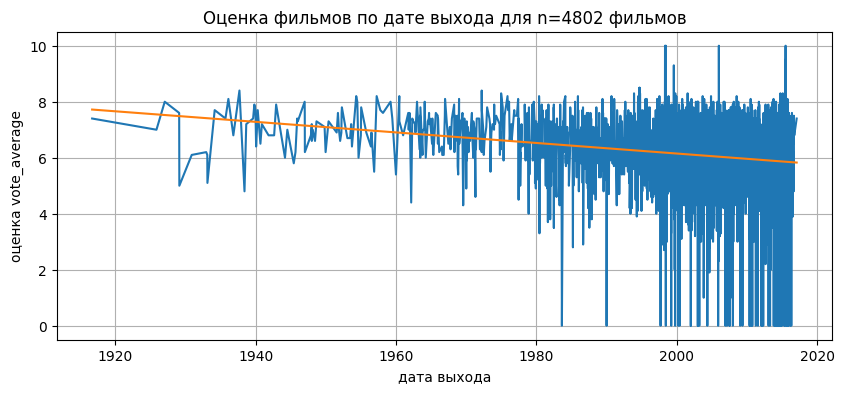

In [20]:
line = movies.dropna(subset=["release_date", "vote_average"]).sort_values("release_date")

t = line["release_date"].map(pd.Timestamp.toordinal)
k, b = np.polyfit(t, line["vote_average"], 1)

plt.figure(figsize=(10, 4))
plt.plot(line["release_date"], line["vote_average"])
plt.plot(line["release_date"], k * t + b)
plt.grid(True)
plt.xlabel("дата выхода")
plt.ylabel("оценка vote_average")
plt.title(f"Оценка фильмов по дате выхода для n={len(line)} фильмов")
plt.show()


### б) Столбчатая диаграмма

Число фильмов по десятилетию выхода — все строки с датой.

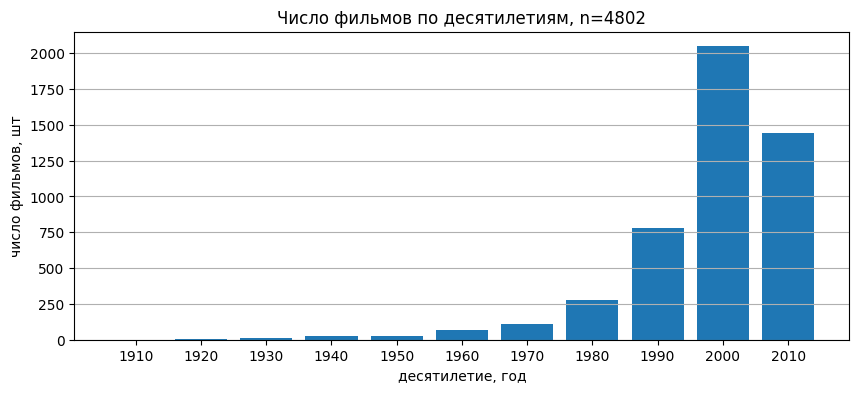

In [21]:
decade_counts = movies["decade"].value_counts().sort_index().dropna()

plt.figure(figsize=(10, 4))
plt.bar(decade_counts.index.astype(int).astype(str), decade_counts.values)
plt.grid(True, axis="y")
plt.xlabel("десятилетие, год")
plt.ylabel("число фильмов, шт")
plt.title(f"Число фильмов по десятилетиям, n={int(decade_counts.sum())}")
plt.show()


### в) Круговая диаграмма

Доли фильмов по основному жанру (первый жанр в списке) — все 4803 строки.

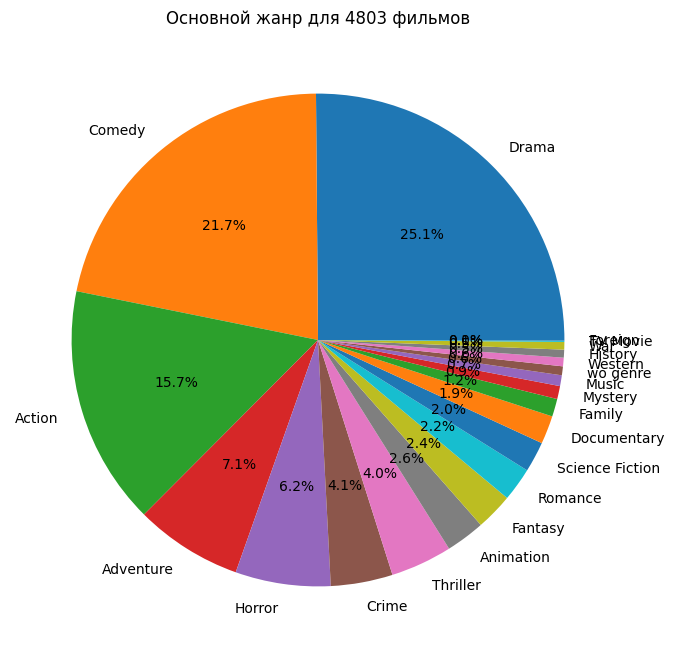

In [22]:
genre_counts = movies["main_genre"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(genre_counts, labels=genre_counts.index, autopct="%1.1f%%")
plt.title(f"Основной жанр для {int(genre_counts.sum())} фильмов")
plt.show()


### г) Скрипичная диаграмма

Распределение оценок `vote_average` по всем фильмам.

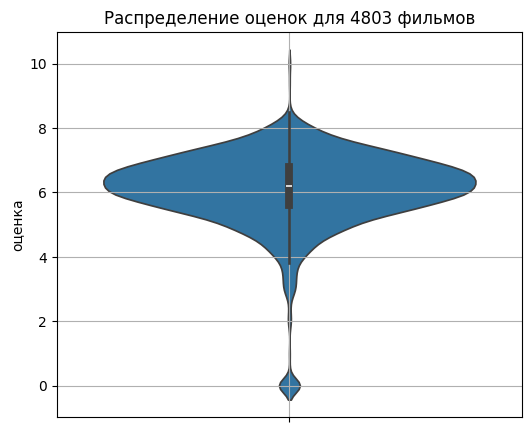

In [23]:
plt.figure(figsize=(6, 5))
sns.violinplot(y=movies["vote_average"])
plt.grid(True)
plt.xlabel("")
plt.ylabel("оценка")
plt.title(f"Распределение оценок для {movies['vote_average'].notna().sum()} фильмов")
plt.show()


### д) Трехкомпонентная диаграмма

Треугольник состава: бюджет, сборы, популярность. Столбцы сначала приводим к шкале 0…1, затем в каждой строке три доли суммируются в 1. 

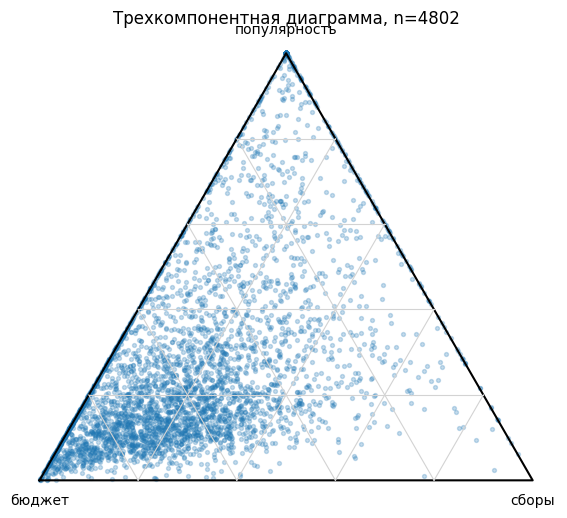

In [24]:
raw = movies[["budget", "revenue", "popularity"]].clip(lower=0)
raw = raw / raw.max()
total = raw.sum(axis=1)
raw = raw.loc[total > 0]
total = total.loc[total > 0]
a = (raw["budget"] / total).to_numpy()
b = (raw["revenue"] / total).to_numpy()
c = (raw["popularity"] / total).to_numpy()

# barycentric → плоскость: A бюджет, B сборы, C популярность
x = 0.5 * (2 * b + c)
y = np.sqrt(3) / 2 * c
h = np.sqrt(3) / 2

plt.figure(figsize=(7, 7))
plt.plot([0, 1, 0.5, 0], [0, 0, h, 0], color="black")
for t in (0.2, 0.4, 0.6, 0.8):
    plt.plot([0.5 * t, 1 - 0.5 * t], [h * t, h * t], color="lightgray", linewidth=0.8)
    bb = np.array([0.0, 1 - t])
    cc = 1 - t - bb
    plt.plot(0.5 * (2 * bb + cc), h * cc, color="lightgray", linewidth=0.8)
    aa = np.array([0.0, 1 - t])
    cc = 1 - t - aa
    plt.plot(0.5 * (2 * t + cc), h * cc, color="lightgray", linewidth=0.8)
plt.scatter(x, y, s=8, alpha=0.25)
plt.text(0, -0.05, "бюджет", ha="center")
plt.text(1, -0.05, "сборы", ha="center")
plt.text(0.5, h + 0.04, "популярность", ha="center")
plt.axis("off")
plt.gca().set_aspect("equal")
plt.title(f"Трехкомпонентная диаграмма, n={len(x)}")
plt.show()


## 4. Заполнение прореженного ряда

Ряд — `vote_average` по дате, 81 значение (≥ 20). Оставляем каждое второе, остальное восстанавливаем: среднее и медиана всего ряда, среднее трёх предыдущих известных, Лагранж (`interpolate(polynomial)`), кубический сплайн. На графиках — оставленные точки, реальные отброшенные и восстановленные.

In [25]:
# 81 точка: последнее оставляем, внутри выкидываем каждое второе → 40 пропусков
s_true = (
    movies.dropna(subset=["release_date", "vote_average"])
    .sort_values("release_date")["vote_average"]
    .iloc[-81:]
    .reset_index(drop=True)
)
s_gap = s_true.copy()
s_gap.iloc[1::2] = np.nan
gap = s_gap.isna()
keep = ~gap
print("всего", len(s_true), "оставлено", int(keep.sum()), "пропусков", int(gap.sum()))


def fill_prev3(s):
    out = s.copy()
    known = np.flatnonzero(s.notna())
    for i in np.flatnonzero(s.isna()):
        prev = known[known < i][-3:]
        out.iloc[i] = s.iloc[prev].mean()
    return out


filled = {
    "mean": s_gap.fillna(s_gap.mean()),
    "median": s_gap.fillna(s_gap.median()),
    "prev3": fill_prev3(s_gap),
    "lagrange": s_gap.interpolate("polynomial", order=3),
    "spline": s_gap.interpolate("cubicspline"),
}
pd.DataFrame({k: v[gap] for k, v in filled.items()}).join(s_true[gap].rename("real")).head()


всего 81 оставлено 41 пропусков 40


,mean,median,prev3,lagrange,spline,real
1,5.85122,6.2,6.200000,6.245927,6.245927,7.1
3,5.85122,6.2,5.900000,5.129073,5.129073,6.3
5,5.85122,6.2,5.833333,7.400280,7.400280,5.3
7,5.85122,6.2,6.166667,3.057305,3.057305,5.8
9,5.85122,6.2,4.300000,2.583000,2.583000,5.9


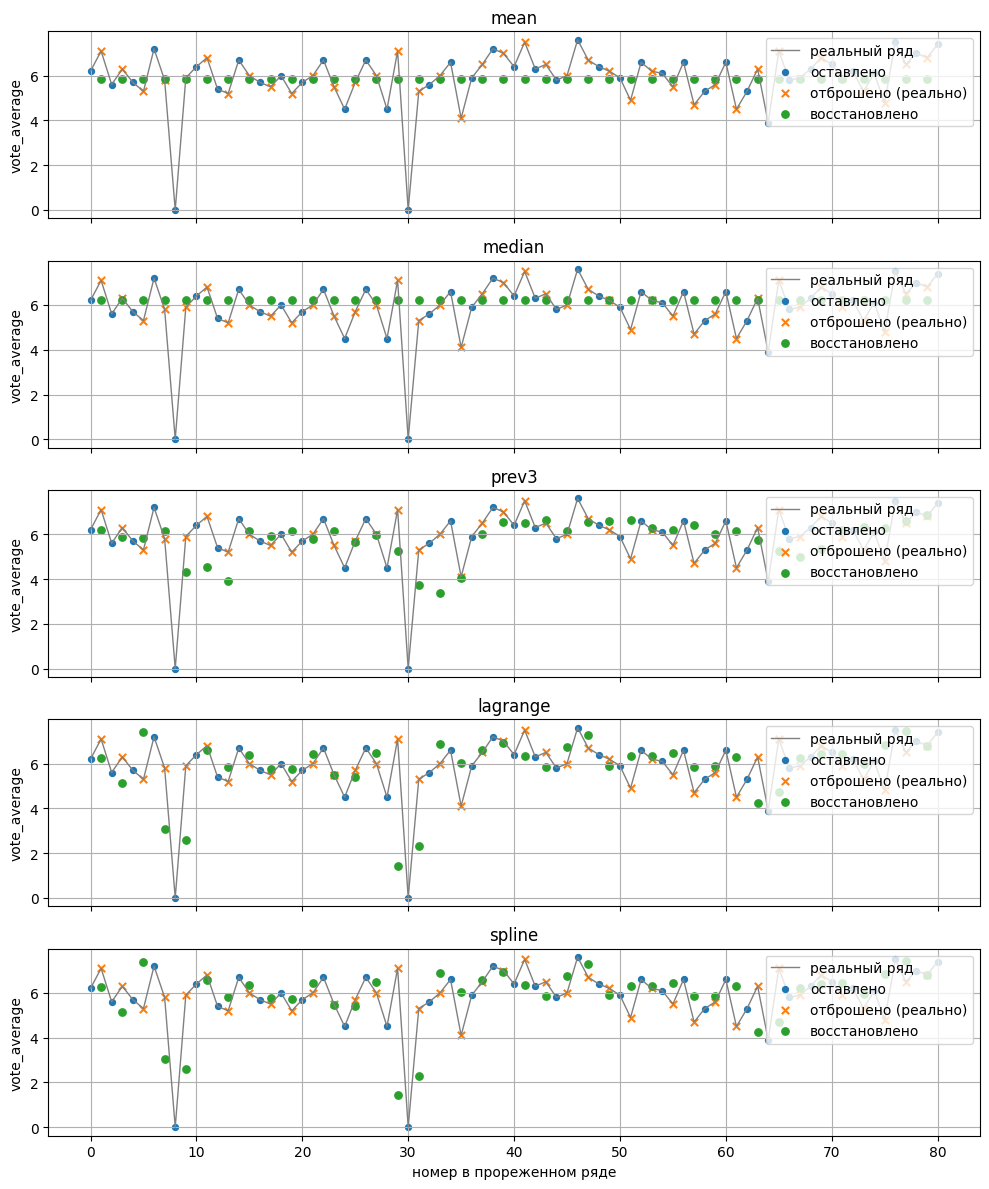

In [27]:
fig, axes = plt.subplots(len(filled), 1, figsize=(10, 12), sharex=True)
x = s_true.index

for ax, (name, pred) in zip(axes, filled.items()):
    ax.plot(x, s_true, color="gray", linewidth=1, label="реальный ряд")
    ax.scatter(x[keep], s_true[keep], s=18, label="оставлено")
    ax.scatter(x[gap], s_true[gap], s=28, marker="x", label="отброшено (реально)")
    ax.scatter(x[gap], pred[gap], s=28, marker="o", label="восстановлено")
    ax.grid(True)
    ax.set_ylabel("vote_average")
    ax.set_title(name)
    ax.legend(loc="upper right")

axes[-1].set_xlabel("номер в прореженном ряде")
plt.tight_layout()
plt.show()


## 5. Недостоверные восстановления

Берём ошибку сплайна: восстановленное − реальное на отброшенных точках. Правило 2σ / 3σ: точка недостоверна, если |ошибка − среднее ошибок| больше 2 или 3 стандартных отклонений. Box-plot и скрипка показывают те же выбросы по размаху ошибок.

n ошибок 40 среднее сплайна= -0.126 σ= 1.584
за 2σ: [9, 29] значений: [-3.317, -5.676]
за 3σ: [29] значений: [-5.676]


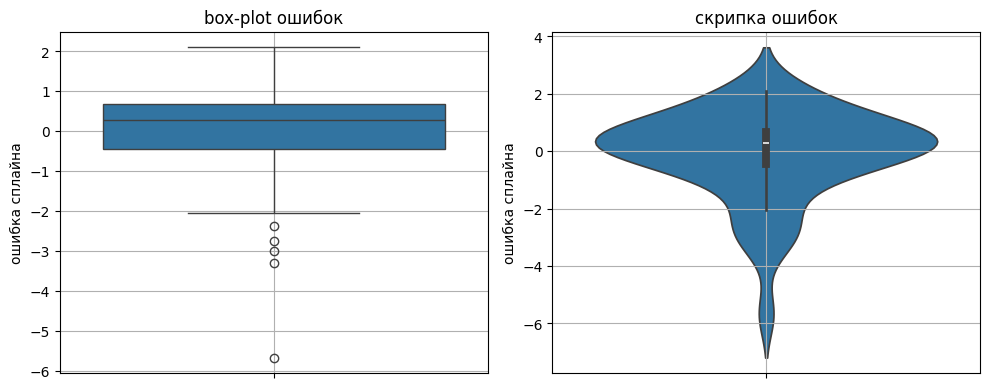

выбросы box-plot (1.5 IQR): [7, 9, 29, 31, 65] [-2.743, -3.317, -5.676, -3.003, -2.387]


In [28]:
err = (filled["spline"] - s_true)[gap]
mu, sigma = err.mean(), err.std()
out_2s = err[np.abs(err - mu) > 2 * sigma]
out_3s = err[np.abs(err - mu) > 3 * sigma]

print("n ошибок", len(err), "среднее сплайна=", round(mu, 3), "σ=", round(sigma, 3))
print("за 2σ:", list(out_2s.index), "значений:", out_2s.round(3).tolist())
print("за 3σ:", list(out_3s.index), "значений:", out_3s.round(3).tolist())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=err, ax=axes[0])
axes[0].set_ylabel("ошибка сплайна")
axes[0].set_title("box-plot ошибок")
axes[0].grid(True)
sns.violinplot(y=err, ax=axes[1])
axes[1].set_ylabel("ошибка сплайна")
axes[1].set_title("скрипка ошибок")
axes[1].grid(True)
plt.tight_layout()
plt.show()

q1, q3 = err.quantile(0.25), err.quantile(0.75)
iqr = q3 - q1
iqr_out = err[(err < q1 - 1.5 * iqr) | (err > q3 + 1.5 * iqr)]
print("выбросы box-plot (1.5 IQR):", list(iqr_out.index), iqr_out.round(3).tolist())
